In [1]:
import rasterio
import pandas as pd
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

In [2]:
def map_wind_with_nearest_neighbor(tif_path, csv_path, target_year=2025, target_doy=179):
    # 1. Open the GeoTIFF to get the exact 2D canvas dimensions
    with rasterio.open(tif_path) as src:
        height, width = src.shape
        
        # 2. Load CSV, skipping the 9 metadata rows so Row 10 becomes the header
        df = pd.read_csv(csv_path, skiprows=9)
        
        # Strip any accidental hidden spaces from the header names
        df.columns = df.columns.str.strip()
        
        # 3. Filter the rows down to your specific target day
        day_filter = (df['YEAR'] == target_year) & (df['DOY'] == target_doy)
        filtered_df = df[day_filter]
        
        if filtered_df.empty:
            raise ValueError(f"No data found in CSV for Year {target_year}, DOY {target_doy}!")
            
        # 4. Convert all station coordinates into pixel positions (Row, Col)
        station_pixels = []
        station_speeds = []
        
        for idx, row in filtered_df.iterrows():
            lon = row['LON']
            lat = row['LAT']
            speed = row['WS2M']
            
            # Use the GeoTIFF header math to find the pixel index of the coordinate
            p_row, p_col = src.index(lon, lat)
            
            station_pixels.append([p_row, p_col])
            station_speeds.append(speed)
            
        station_pixels = np.array(station_pixels)
        station_speeds = np.array(station_speeds)
        
        # 5. Build the Spatial Lookup Tree using the station pixel coordinates
        spatial_tree = cKDTree(station_pixels)
        
        # 6. Generate a coordinate list of EVERY single pixel in your 30km map
        rows, cols = np.indices((height, width))
        all_pixel_coords = np.column_stack((rows.ravel(), cols.ravel()))
        
        # 7. Query the tree: Find the closest station for all pixels instantly
        _, closest_station_indices = spatial_tree.query(all_pixel_coords)
        
        # 8. Extract the wind speeds and reshape them back into the 2D grid layout
        flat_wind_grid = station_speeds[closest_station_indices]
        wind_grid_2d = flat_wind_grid.reshape(height, width)
        
        print("--- Execution Summary ---")
        print(f"Skipped metadata headers successfully.")
        print(f"Target Date: Year {target_year}, DOY {target_doy}")
        print(f"Generated Seamless 2D Wind Grid Shape: {wind_grid_2d.shape}")
        
        return wind_grid_2d
    

In [3]:
def map_wind_smooth_bilinear(tif_path, csv_path, target_year=2025, target_doy=179):
    with rasterio.open(tif_path) as src:
        height, width = src.shape
        
        # 1. Load and filter CSV
        df = pd.read_csv(csv_path, skiprows=9)
        df.columns = df.columns.str.strip()
        filtered_df = df[(df['YEAR'] == target_year) & (df['DOY'] == target_doy)]
        
        # 2. Extract unique, sorted grid lines from the NASA CSV
        # Because NASA data is a regular grid, sorting gives us clean axes
        unique_lats = np.sort(filtered_df['LAT'].unique())
        unique_lons = np.sort(filtered_df['LON'].unique())
        
        # 3. Pivot the flat CSV wind speeds into a structured 2D matrix matching the axes
        # Shape will be (len(unique_lats), len(unique_lons))
        pivot_table = filtered_df.pivot(index='LAT', columns='LON', values='WS2M')
        wind_source_matrix = pivot_table.loc[unique_lats, unique_lons].values
        
        # 4. Initialize the True Bilinear Interpolator
        # bounds_error=False tells it to handle pixels sticking out past the weather grid edges
        interp_function = RegularGridInterpolator(
            points=(unique_lats, unique_lons), 
            values=wind_source_matrix, 
            method='linear', # 'linear' on a RegularGridInterpolator IS bilinear
            bounds_error=False,
            fill_value=None # Extrapolates edge values automatically
        )
        
        # 5. Generate target coordinates for every 10m pixel
        rows, cols = np.indices((height, width))
        xs, ys = rasterio.transform.xy(src.transform, rows.ravel(), cols.ravel())
        target_points = np.column_stack((ys, xs)) # Format as (Lat, Lon)
        
        # 6. Run the true bilinear interpolation
        print("Executing true bilinear grid interpolation...")
        flat_bilinear_grid = interp_function(target_points)
        
        return flat_bilinear_grid.reshape(height, width)

In [4]:
TIF_FILE_PATH = "test_runs/test_raw_algae_map/lake_algae_2025.tif" 
CSV_FILE_PATH = "test_runs/test_data/Wind Speed At 2Meters (Western Basin Area) - POWER_Regional_Daily_20250628_20260628 copy.csv"

In [5]:
# Extracts June 28, 2025 data and builds the matrix
wind_matrix_nn = map_wind_with_nearest_neighbor(TIF_FILE_PATH, CSV_FILE_PATH, target_year=2025, target_doy=179)

--- Execution Summary ---
Skipped metadata headers successfully.
Target Date: Year 2025, DOY 179
Generated Seamless 2D Wind Grid Shape: (3006, 4002)


In [9]:
wind_matrix_smooth = map_wind_smooth_bilinear(TIF_FILE_PATH, CSV_FILE_PATH, target_year=2025, target_doy=179)

Executing true bilinear grid interpolation...


In [10]:
wind_matrix_smooth

array([[2.46117308, 2.46126166, 2.46135025, ..., 2.81542626, 2.81551484,
        2.81560343],
       [2.46112959, 2.46121817, 2.46130675, ..., 2.81536728, 2.81545586,
        2.81554444],
       [2.46108611, 2.46117468, 2.46126326, ..., 2.81530831, 2.81539688,
        2.81548546],
       ...,
       [2.33058625, 2.3306632 , 2.33074015, ..., 2.63832308, 2.63840004,
        2.63847699],
       [2.33054276, 2.33061971, 2.33069666, ..., 2.63826411, 2.63834106,
        2.63841801],
       [2.33049928, 2.33057622, 2.33065317, ..., 2.63820513, 2.63828208,
        2.63835902]], shape=(3006, 4002))

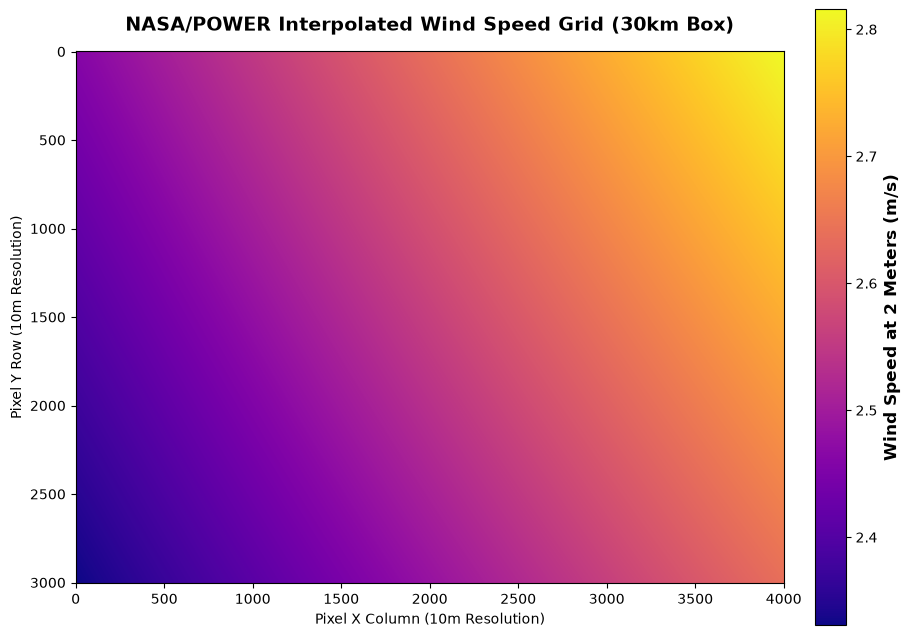

In [11]:
# Assuming 'final_wind_channel' is the 2D array generated from the previous script
plt.figure(figsize=(10, 8), dpi=100)

# 1. Display the 2D array as an image
# 'plasma', 'viridis', or 'coolwarm' are great colormaps for wind data
im = plt.imshow(wind_matrix_smooth, cmap='plasma')

# 2. Add a colorbar scale on the side so you know what the colors mean
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label('Wind Speed at 2 Meters (m/s)', fontsize=12, fontweight='bold')

# 3. Add titles and axis labels
plt.title('NASA/POWER Interpolated Wind Speed Grid (30km Box)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Pixel X Column (10m Resolution)', fontsize=10)
plt.ylabel('Pixel Y Row (10m Resolution)', fontsize=10)

# 4. Turn on a subtle grid layout over the pixels
plt.grid(False) 

# 5. Save the image to your disk (Great for .py scripts)
#plt.savefig('wind_speed_grid_visualization.png', bbox_inches='tight', dpi=300)

# 6. Render the plot to the screen
plt.show()